# Linear Regression and Gradient Descent: A Visual Journey

Imagine you want to predict someone's salary from years of experience, or a house price from its square footage. You're looking for a straight line that best fits a cloud of data points. That process is called **Linear Regression**.

But "best fits" needs a precise mathematical definition. And finding the best parameters automatically — without trial and error — is the job of **Gradient Descent**: the optimization engine at the heart of nearly all modern machine learning, from simple classifiers to large language models.

By the end of this notebook, you will:

- Understand what a **loss function** is and why minimizing it gives you the best line
- See how **gradient descent** navigates a mathematical surface to find optimal parameters
- Watch both processes unfold simultaneously in a synchronized interactive visualization
- Grasp why the same algorithm that fits this simple line also trains deep neural networks



## The big picture

There are infinitely many straight lines through any dataset. We need a principled way to rank them — and then an algorithm to automatically find the best one.

This notebook tells that story in four acts:

1. **Build a dataset** — generate noisy data from a known true line
2. **Define "best"** — write a loss function that numerically scores every possible line
3. **Minimize the loss** — use gradient descent to walk downhill on the loss surface
4. **Visualize the journey** — watch gradient descent work in real time across two synchronized views



## Our model

A straight line is completely defined by two numbers:

$$\hat{y} = mx + b$$

- $m$ **(slope)**: how much $y$ changes when $x$ increases by a small quantity
- $b$ **(intercept)**: the value of $\hat{y}$ when $x = 0$

Our goal is to find the values of $m$ and $b$ that make this line fit our data as closely as possible.

In [ ]:
# Uncomment the line below if running in Google Colab for the first time
# !pip install plotly

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display

np.random.seed(42)
print("Setup complete.")

Setup complete.


## Step 1 — Create a Dataset

We start by generating data from a known relationship:

$$y = 4x + 7 + \varepsilon, \qquad \varepsilon \sim \mathcal{N}(0,\ 8)$$

In plain English: the true relationship is $y = 4x + 7$, but every measurement is contaminated by random noise $\varepsilon$ drawn from a normal distribution with standard deviation 8.

**Why use synthetic data?**

Real datasets keep their true structure hidden from you. When *learning* how an algorithm works, it helps enormously to already know the answer — so you can verify whether the algorithm actually found it. Here, the ground truth we're trying to recover is:

- **True slope:** $m^* = 4$
- **True intercept:** $b^* = 7$

After gradient descent runs, we will compare its result to these values.

**Why add noise?**

Real-world data is never perfectly clean. Sensor errors, missing variables, and natural variation all add noise to measurements. Including noise here makes the problem realistic: even with the optimal parameters, the fit won't be perfect, and the final loss will be positive. That is the norm in practice, not the exception.

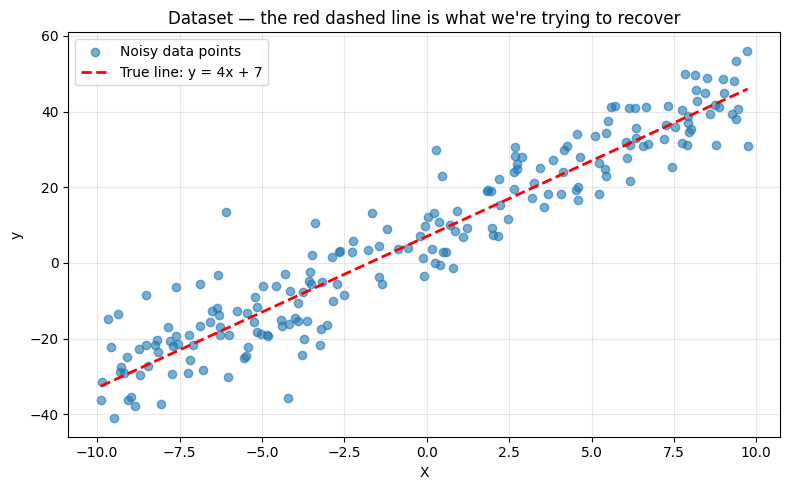

Dataset: 200 samples
True parameters — slope: m = 4, intercept: b = 7


In [ ]:
n_samples = 200

X = np.random.uniform(-10, 10, n_samples)

true_m = 4
true_b = 7
noise = np.random.normal(0, 8, n_samples)
y = true_m * X + true_b + noise

# Plot the noisy data alongside the hidden true line
x_range = np.array([X.min(), X.max()])

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, label="Noisy data points")
plt.plot(x_range, true_m * x_range + true_b, 'r--', linewidth=2,
         label=f"True line: y = {true_m}x + {true_b}")
plt.title("Dataset — the red dashed line is what we're trying to recover")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Dataset: {n_samples} samples")
print(f"True parameters — slope: m = {true_m}, intercept: b = {true_b}")

## Step 2 — The Loss Function: Measuring How Wrong We Are

Given a slope $m$ and intercept $b$, our model predicts $\hat{y}_i = mx_i + b$ for each data point $x_i$.

The difference between our prediction and the actual value is called the **residual**:

$$e_i = \hat{y}_i - y_i = (mx_i + b) - y_i$$

A positive residual means we predicted too high. Negative means too low. We need a single number that summarizes how wrong we are across *all* data points.

We use the **Mean Squared Error (MSE)**:

$$J(m, b) = \frac{1}{n} \sum_{i=1}^{n} \bigl(mx_i + b - y_i\bigr)^2$$

**Why square the errors?**
- Squaring makes every residual positive — overestimates and underestimates both count as "wrong"
- Squaring penalizes large errors much more heavily (a residual of 10 contributes 100 to the loss)
- The squared form produces a smooth, differentiable surface that gradient descent can navigate efficiently




## The key realization: loss lives in parameter space

Notice that $J$ is a function of $m$ and $b$ — **not** of $x$.

For any fixed dataset, every pair $(m, b)$ produces exactly one loss value. This means we can visualize the loss as a **surface** over all possible slopes and intercepts. Every point on that surface corresponds to a specific regression line and its quality score. We build this surface in the next step.




## Gradients: which direction is downhill?

To minimize $J$, we need to know how the loss changes when we nudge each parameter. These rates of change are the **partial derivatives** (gradients):

$$\frac{\partial J}{\partial m} = \frac{2}{n} \sum_{i=1}^{n} \bigl(mx_i + b - y_i\bigr)\, x_i$$

$$\frac{\partial J}{\partial b} = \frac{2}{n} \sum_{i=1}^{n} \bigl(mx_i + b - y_i\bigr)$$

If $\partial J / \partial m$ is positive, then increasing $m$ increases the loss — so we should decrease $m$. Gradient descent exploits this logic at every step.

<details>
<summary><strong>&#9654; Click to show: full derivation of the gradient formulas</strong></summary>

<br>

### Deriving $\partial J / \partial m$

Start with the MSE definition:

$$J(m, b) = \frac{1}{n} \sum_{i=1}^{n} (mx_i + b - y_i)^2$$

Let $u_i = mx_i + b - y_i$ (the residual for point $i$). Then $J = \frac{1}{n}\sum_i u_i^2$.

Apply the chain rule — the outer derivative of $u_i^2$ is $2u_i$, and the inner derivative of $u_i$ with respect to $m$ is $x_i$:

$$\frac{\partial J}{\partial m} = \frac{1}{n}\sum_{i=1}^{n} 2u_i \cdot \frac{\partial u_i}{\partial m} = \frac{2}{n}\sum_{i=1}^{n} (mx_i + b - y_i)\, x_i$$

### Deriving $\partial J / \partial b$

By the same chain rule argument, $\frac{\partial u_i}{\partial b} = 1$ (since $b$ is a plain additive constant):

$$\frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^{n} (mx_i + b - y_i) \cdot 1 = \frac{2}{n}\sum_{i=1}^{n} (mx_i + b - y_i)$$

### Geometric interpretation

The gradient vector $\nabla J = \left(\frac{\partial J}{\partial m},\ \frac{\partial J}{\partial b}\right)$ points in the direction of **steepest ascent** on the loss surface. Gradient descent moves in the **negative** gradient direction — downhill — at every step. That single idea is the whole algorithm.

</details>

In [ ]:
def predict(x, m, b):
    return m * x + b


def compute_loss(m, b, X, y):
    y_pred = predict(X, m, b)
    return np.mean((y_pred - y) ** 2)


# Build a grid of (m, b) pairs to evaluate the loss at every combination
m_values = np.linspace(-1, 8, 120)
b_values = np.linspace(-5, 20, 120)

M, B = np.meshgrid(m_values, b_values)

# Compute loss at each grid point (this takes a few seconds)
Z = np.zeros_like(M)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        Z[i, j] = compute_loss(M[i, j], B[i, j], X, y)

print(f"Loss surface computed. Grid: {Z.shape[0]}×{Z.shape[1]} = {Z.size} evaluations")
print(f"Loss range on grid: {Z.min():.1f} (best) to {Z.max():.1f} (worst)")

# The grid minimum should be close to the true parameters
best_idx = np.unravel_index(Z.argmin(), Z.shape)
print(f"Best (m, b) on grid: m = {M[best_idx]:.2f}, b = {B[best_idx]:.2f}  (true: m={true_m}, b={true_b})")

Loss surface computed. Grid: 120×120 = 14400 evaluations
Loss range on grid: 59.8 (best) to 1111.9 (worst)
Best (m, b) on grid: m = 3.99, b = 7.61  (true: m=4, b=7)


## Step 3 — The Loss Surface: A Landscape to Navigate

We just evaluated $J(m, b)$ for a $120 \times 120$ grid of parameter combinations. Each point on that grid represents one regression line, and its value is how badly that line fits the data.

Plotting these values as a 3D surface reveals **a bowl**.



## Why the bowl shape matters deeply

This bowl is not just aesthetically pleasing — it has a critical mathematical consequence. Because MSE is a sum of *squares* of *linear* functions of $m$ and $b$, it forms a **convex** function.

Convexity gives us a remarkable guarantee:

> A convex function has exactly **one** global minimum. There are no local minima to get trapped in, no flat plateaus to stall on, no misleading valleys.

This means gradient descent, starting from *anywhere* on the surface, will always converge to the unique optimal parameters $(m^*, b^*)$. For linear regression with MSE, there is no such thing as a "bad starting point."

The bottom of the bowl is the best-fit line.



## What to look for in the plot below

When you rotate the 3D surface:
- The lowest point of the bowl should be near $m = 4,\ b = 7$ — the true parameters we used to generate the data
- Moving away from that point in any direction raises the loss
- The bowl is elongated, not perfectly circular — this means the loss changes faster in one direction than the other (related to the scale and spread of $X$)

In [ ]:
fig = go.Figure()

fig.add_trace(
    go.Surface(
        x=M,
        y=B,
        z=Z,
        colorscale='Viridis',
        opacity=0.9
    )
)

fig.update_layout(
    title="3D Loss Surface",
    scene=dict(
        xaxis_title='Slope (m)',
        yaxis_title='Intercept (b)',
        zaxis_title='Loss'
    ),
    width=900,
    height=700
)

fig.show()

## Step 4 — Gradient Descent: Rolling Downhill

We have a bowl-shaped loss surface and a formula for its slope at any point. Gradient descent uses that slope to take repeated downhill steps toward the minimum.



## The algorithm in plain English

1. **Start** at an initial position — we use $m_0 = 0,\ b_0 = 0$
2. **Measure the local slope** by computing the gradients $\frac{\partial J}{\partial m}$ and $\frac{\partial J}{\partial b}$
3. **Step downhill**: move a small amount in the direction *opposite* to the gradient
4. **Repeat** until the loss stops decreasing meaningfully



## The update rule

At each iteration, both parameters are updated simultaneously:

$$m \;\leftarrow\; m - \alpha \cdot \frac{\partial J}{\partial m}$$

$$b \;\leftarrow\; b - \alpha \cdot \frac{\partial J}{\partial b}$$

The arrow $\leftarrow$ means "replace the old value with the right-hand side." The constant $\alpha$ is the **learning rate** — it controls the size of each step.

**Why subtract the gradient?** Because the gradient points *uphill*. Subtracting it moves us *downhill* — toward the minimum.



## Choosing the learning rate $\alpha$

| Learning rate | What happens |
|---|---|
| Too small | Steps are tiny; takes many iterations to reach the minimum |
| Just right | Smooth, steady descent; converges efficiently |
| Too large | Overshoots the minimum; oscillates or diverges |

We use $\alpha = 0.003$ here. In Step 8, we run experiments with three different values to see all three behaviors side by side.



## An important point about gradient descent

Gradient descent has no map of the loss landscape. It has no idea where the minimum is. It can only feel the local slope at its current position.

Yet that purely local information, applied repeatedly, is sufficient to find the global minimum of any convex function. This is a foundational result — and the intuition behind it is exactly what this notebook is designed to build.

In [ ]:
learning_rate = 0.003
iterations = 200

# Start at the origin in parameter space
m = 0
b = 0

# Record the full history so we can animate it later
m_history = [0]
b_history = [0]
loss_history = []

n = len(X)

for step in range(iterations):
    y_pred = predict(X, m, b)

    # Compute gradients using the formulas derived in Step 2
    dm = (2 / n) * np.sum((y_pred - y) * X)
    db = (2 / n) * np.sum(y_pred - y)

    # Step downhill (subtract because gradient points uphill)
    m -= learning_rate * dm
    b -= learning_rate * db

    current_loss = compute_loss(m, b, X, y)
    m_history.append(m)
    b_history.append(b)
    loss_history.append(current_loss)

print(f"Gradient descent complete — {iterations} iterations")
print(f"Found:  m = {m:.4f},  b = {b:.4f}")
print(f"True:   m = {true_m},       b = {true_b}")
print(f"Final loss: {current_loss:.4f}")

Gradient descent complete — 200 iterations
Found:  m = 3.9471,  b = 5.2503
True:   m = 4,       b = 7
Final loss: 64.9436


## Step 5 — Did it Converge? The Loss Curve

The simplest way to verify that gradient descent worked is to plot the **loss at each iteration**. This is called the **loss curve** (or training curve), and it is the first diagnostic every ML practitioner checks after running optimization.

**A healthy loss curve:**
- Drops steeply in early iterations — when the parameters are far from the minimum and gradients are large
- Flattens as it approaches the minimum — when gradients shrink near the bottom of the bowl
- Settles at a positive value, not zero — because the noise in the data means no line fits perfectly

**Warning signs to know:**
- Curve goes *up*: learning rate is too large
- Curve barely moves: learning rate is too small, or not enough iterations
- Curve oscillates: learning rate is too large and the optimizer is bouncing around the minimum

We will induce all three of these failure modes in Step 8.

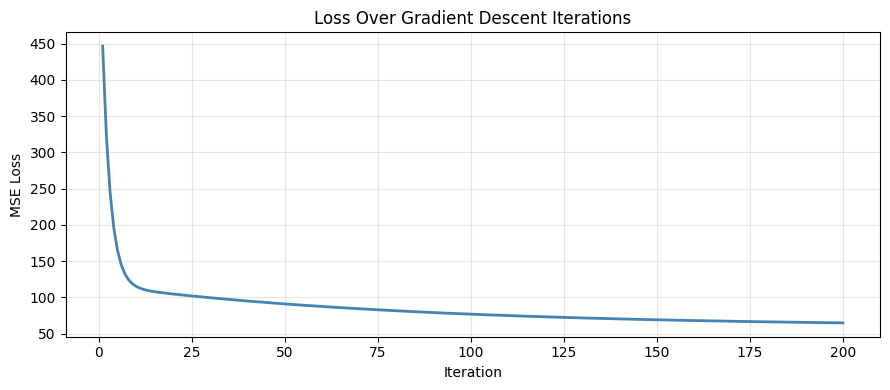

Starting loss (iteration 1):  446.65
Final loss   (iteration 200): 64.94
Loss reduced by 85.5%


In [ ]:
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, color='steelblue', linewidth=2)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Loss Over Gradient Descent Iterations")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Starting loss (iteration 1):  {loss_history[0]:.2f}")
print(f"Final loss   (iteration {iterations}): {loss_history[-1]:.2f}")
print(f"Loss reduced by {(1 - loss_history[-1] / loss_history[0]) * 100:.1f}%")

## Step 6 — Watching Gradient Descent in Action

This is the central visualization of the notebook. Use the **slider** at the bottom to move through gradient descent iterations.

**Two synchronized panels update together as you drag the slider:**

**Left panel — Parameter Space (top-down view of the loss bowl)**
- The contours are like a topographic map: rings closer together = steeper slope
- Darker color = lower loss = closer to the optimal parameters
- The trail shows the path gradient descent has walked so far
- The dot is the current parameter position $(m_t, b_t)$ at iteration $t$

**Right panel — Data Space**
- The scatter plot is your raw data
- The line is the regression line produced by the current $(m_t, b_t)$


## What to watch for

**Drag the slider slowly from 0 to 80:**

- At iteration 0 the line is flat at $y=0$ — both parameters start at zero
- In the first ~10 iterations the line moves dramatically; the parameter dot takes large jumps
- After ~30 iterations the line barely changes between steps; the dot is nearly at the bullseye
- At iteration 80 the line sits close to the true hidden line (the dashed red line from Step 1)

**The central insight to internalize:**

Gradient descent moves through *parameter space* $(m, b)$ — it has nothing to do with moving points in the data plot. The regression line improves only because the *parameters* improve. The two panels show the same underlying process from two different perspectives.

In [ ]:
frames = []

x_line = np.linspace(X.min(), X.max(), 200)

for i in range(len(m_history)):

    current_m = m_history[i]
    current_b = b_history[i]
    y_line = current_m * x_line + current_b

    frame = go.Frame(
        data=[
            go.Contour(
                x=m_values, y=b_values, z=Z,
                colorscale='Viridis', showscale=False,
                contours=dict(showlabels=False)
            ),
            go.Scatter(
                x=m_history[:i+1], y=b_history[:i+1],
                mode='lines+markers', marker=dict(size=6), name='GD Path'
            ),
            go.Scatter(
                x=[current_m], y=[current_b],
                mode='markers', marker=dict(size=14), name='Current Position'
            ),
            go.Scatter(
                x=X, y=y, mode='markers', marker=dict(size=6), name='Data'
            ),
            go.Scatter(
                x=x_line, y=y_line,
                mode='lines', line=dict(width=4), name='Regression Line'
            ),
        ],
        name=str(i)
    )
    frames.append(frame)

print(f"Frames created: {len(frames)}")

Frames created: 201


In [ ]:
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=(
        "Loss Contours and GD Path",
        "Regression Fit Evolution"
    )
)

# Initial frame data

initial_m = m_history[0]
initial_b = b_history[0]

initial_line = initial_m * x_line + initial_b

# LEFT PANEL

fig.add_trace(
    go.Contour(
        x=m_values,
        y=b_values,
        z=Z,
        colorscale='Viridis',
        showscale=False
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=[initial_m],
        y=[initial_b],
        mode='markers',
        marker=dict(size=12),
        name='Current Position'
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Scatter(
        x=[initial_m],
        y=[initial_b],
        mode='lines+markers',
        name='GD Path'
    ),
    row=1,
    col=1
)

# RIGHT PANEL

fig.add_trace(
    go.Scatter(
        x=X,
        y=y,
        mode='markers',
        marker=dict(size=6),
        name='Data'
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Scatter(
        x=x_line,
        y=initial_line,
        mode='lines',
        line=dict(width=4),
        name='Regression Line'
    ),
    row=1,
    col=2
)

# Frames

fig.frames = frames

# Slider

sliders = [
    {
        "steps": [
            {
                "args": [
                    [str(k)],
                    {
                        "frame": {"duration": 0, "redraw": True},
                        "mode": "immediate"
                    }
                ],
                "label": str(k),
                "method": "animate"
            }
            for k in range(len(frames))
        ],
        "currentvalue": {
            "prefix": "Iteration: "
        }
    }
]

# Layout

fig.update_layout(
    width=1300,
    height=650,
    sliders=sliders,
    title="Gradient Descent: Parameter Space vs Data Space",
    showlegend=False
)

fig.update_xaxes(title_text="Slope (m)", row=1, col=1)
fig.update_yaxes(title_text="Intercept (b)", row=1, col=1)

fig.update_xaxes(title_text="X", row=1, col=2)
fig.update_yaxes(title_text="y", row=1, col=2)

fig.show()

## Step 7 — The 3D Trajectory on the Loss Surface

We have seen gradient descent from above (the contour map). Now let's see it from the side — the path overlaid on the actual 3D bowl.

Each marker on the path below is one iteration. Drag the 3D plot to rotate it and explore different angles.

**What to notice:**
- The path starts high on the surface: large loss at $m=0,\ b=0$
- Each step moves to a slightly lower point on the bowl
- The path curves as it descends — it does not go straight to the bottom because the bowl is elongated, not perfectly circular
- The path terminates near the very bottom, close to the true parameters $(m=4,\ b=7)$

This 3D view makes something visceral that was previously abstract: *minimizing a loss function is literally rolling a ball to the bottom of a bowl*.

In [ ]:
loss_points = [compute_loss(m_history[i], b_history[i], X, y) for i in range(len(m_history))]

fig = go.Figure()

fig.add_trace(go.Surface(x=M, y=B, z=Z, colorscale='Viridis', opacity=0.85))

fig.add_trace(
    go.Scatter3d(
        x=m_history, y=b_history, z=loss_points,
        mode='lines+markers',
        marker=dict(size=4),
        line=dict(width=5),
        name='Gradient Descent Path'
    )
)

fig.update_layout(
    title="3D Gradient Descent Trajectory on Loss Surface",
    scene=dict(xaxis_title='Slope (m)', yaxis_title='Intercept (b)', zaxis_title='Loss'),
    width=1000, height=800
)

fig.show()

## Step 8 — Learning Rate Experiments

Everything so far used $\alpha = 0.003$. But what if we had chosen differently?

The **learning rate** is the most consequential hyperparameter in gradient descent. We run the same algorithm three times — same data, same starting point — with only the learning rate changed:

| Experiment | Learning rate | Expected behavior |
|---|---|---|
| Too small | $\alpha = 0.0001$ | Takes tiny steps; barely progresses in 80 iterations |
| Just right | $\alpha = 0.003$ | Smooth convergence to a low loss |
| Too large | $\alpha = 0.02$ | Overshoots; oscillates or diverges |

Compare the three loss curves and notice how drastically the choice of $\alpha$ affects the outcome.

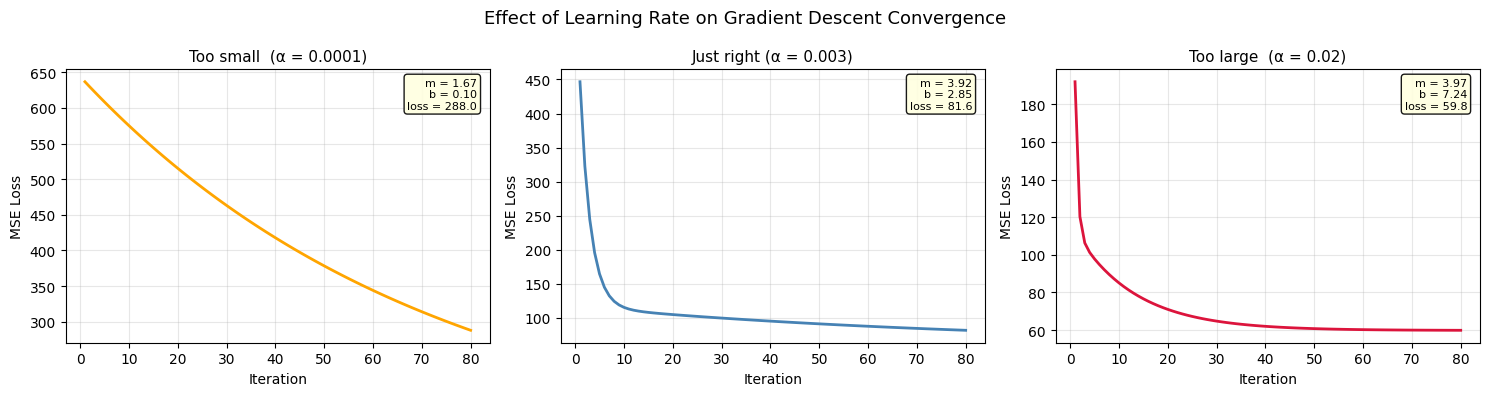

In [ ]:
def run_gd(X, y, learning_rate, iterations=80):
    m, b = 0.0, 0.0
    n = len(X)
    losses = []
    for _ in range(iterations):
        y_pred = m * X + b
        dm = (2 / n) * np.sum((y_pred - y) * X)
        db = (2 / n) * np.sum(y_pred - y)
        m -= learning_rate * dm
        b -= learning_rate * db
        losses.append(np.mean((m * X + b - y) ** 2))
    return m, b, losses


configs = [
    (0.0001, "Too small  (α = 0.0001)", "orange"),
    (0.003,  "Just right (α = 0.003)",  "steelblue"),
    (0.02,   "Too large  (α = 0.02)",   "crimson"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (lr, label, color) in zip(axes, configs):
    final_m, final_b, losses = run_gd(X, y, lr)

    cap = 8000
    display_losses = [min(l, cap) for l in losses]
    clipped = any(l > cap for l in losses)

    ax.plot(range(1, 81), display_losses, color=color, linewidth=2)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("MSE Loss")
    ax.grid(True, alpha=0.3)

    if clipped:
        ax.text(40, cap * 0.75, "Loss exploded\n(y-axis capped)",
                ha='center', color='crimson', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.8))
    else:
        result_text = f"m = {final_m:.2f}\nb = {final_b:.2f}\nloss = {losses[-1]:.1f}"
        ax.text(0.97, 0.97, result_text, transform=ax.transAxes,
                fontsize=8, va='top', ha='right',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.suptitle("Effect of Learning Rate on Gradient Descent Convergence", fontsize=13)
plt.tight_layout()
plt.show()

## Conclusion — What You've Learned

Let's step back and summarize the journey.

You started with a cloud of noisy data and one question: *"What is the best straight line through this data?"*

To answer it, you worked through four stages:

1. **Defined "best"** using the MSE loss function — a single number that decreases as your line improves
2. **Mapped the loss landscape** — a convex bowl in 2D parameter space, where every point represents a different line with a different quality score
3. **Applied gradient descent** — an algorithm that uses local slope information to walk downhill, step by step, without any global knowledge of where the minimum is
4. **Visualized the process** — through the loss curve, the interactive dual-panel visualization, the 3D trajectory, and the learning rate experiments



## Why this matters beyond linear regression

The exact loop you just ran powers:

| Application | What's different |
|---|---|
| Logistic regression | Different loss function (cross-entropy instead of MSE) |
| Neural networks | Millions of parameters, non-convex loss surface |
| Large language models | Billions of parameters, vastly more complex architecture |

The core logic — *compute gradient, step downhill, repeat* — is identical across all of them. The intuition you built by watching a 2D contour plot is the right mental model to carry into those more complex settings.



## Things to try

- Change `true_m` and `true_b` in Step 1 and re-run the whole notebook. Does gradient descent still find the right values?
- Increase the noise standard deviation (e.g., from 8 to 20). How does this affect the final loss? Does it affect the recovered parameters?
- Try starting gradient descent from a very different point (change the initial `m = 0, b = 0`). Does it still converge to the same place?
- Experiment with even more extreme learning rates in Step 8. What happens at $\alpha = 0.001$ or $\alpha = 0.05$?